## IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## IMPORTING DATASET

In [2]:
df= pd.read_csv("titanic.csv")

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [5]:
df.set_index('PassengerId', inplace=True)

In [6]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## DATA PREPROCESSING

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [8]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [9]:
df.shape

(891, 11)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

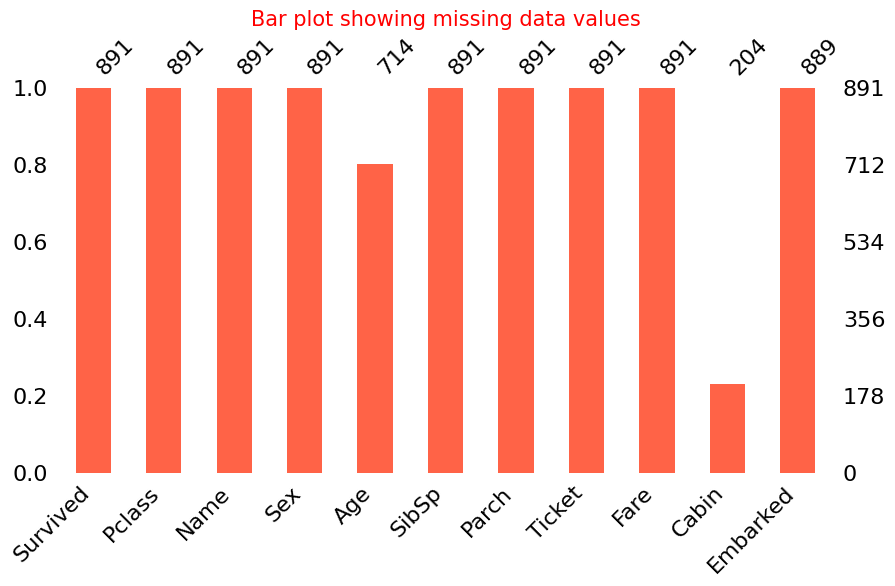

In [12]:
import missingno as ms

ms.bar(df,figsize = (10,5),color="tomato")
plt.title("Bar plot showing missing data values", size = 15,c="r")
plt.show()

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


[Text(0, 0, '342')]

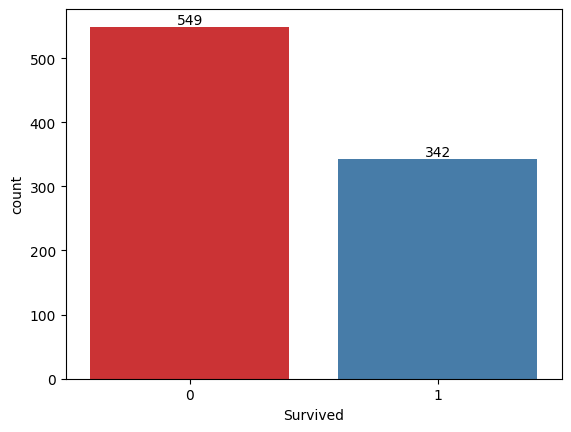

In [14]:
ax = sns.countplot(x=df["Survived"], palette="Set1")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

In [15]:
df.drop(['Cabin'], axis=1, inplace=True)
df.shape

(891, 10)

In [16]:
df["Embarked"].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [17]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [18]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [19]:
df["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [20]:
df.drop(["Name","Ticket"],axis=1,inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


Text(0.5, 1.0, 'Distribution Of Age')

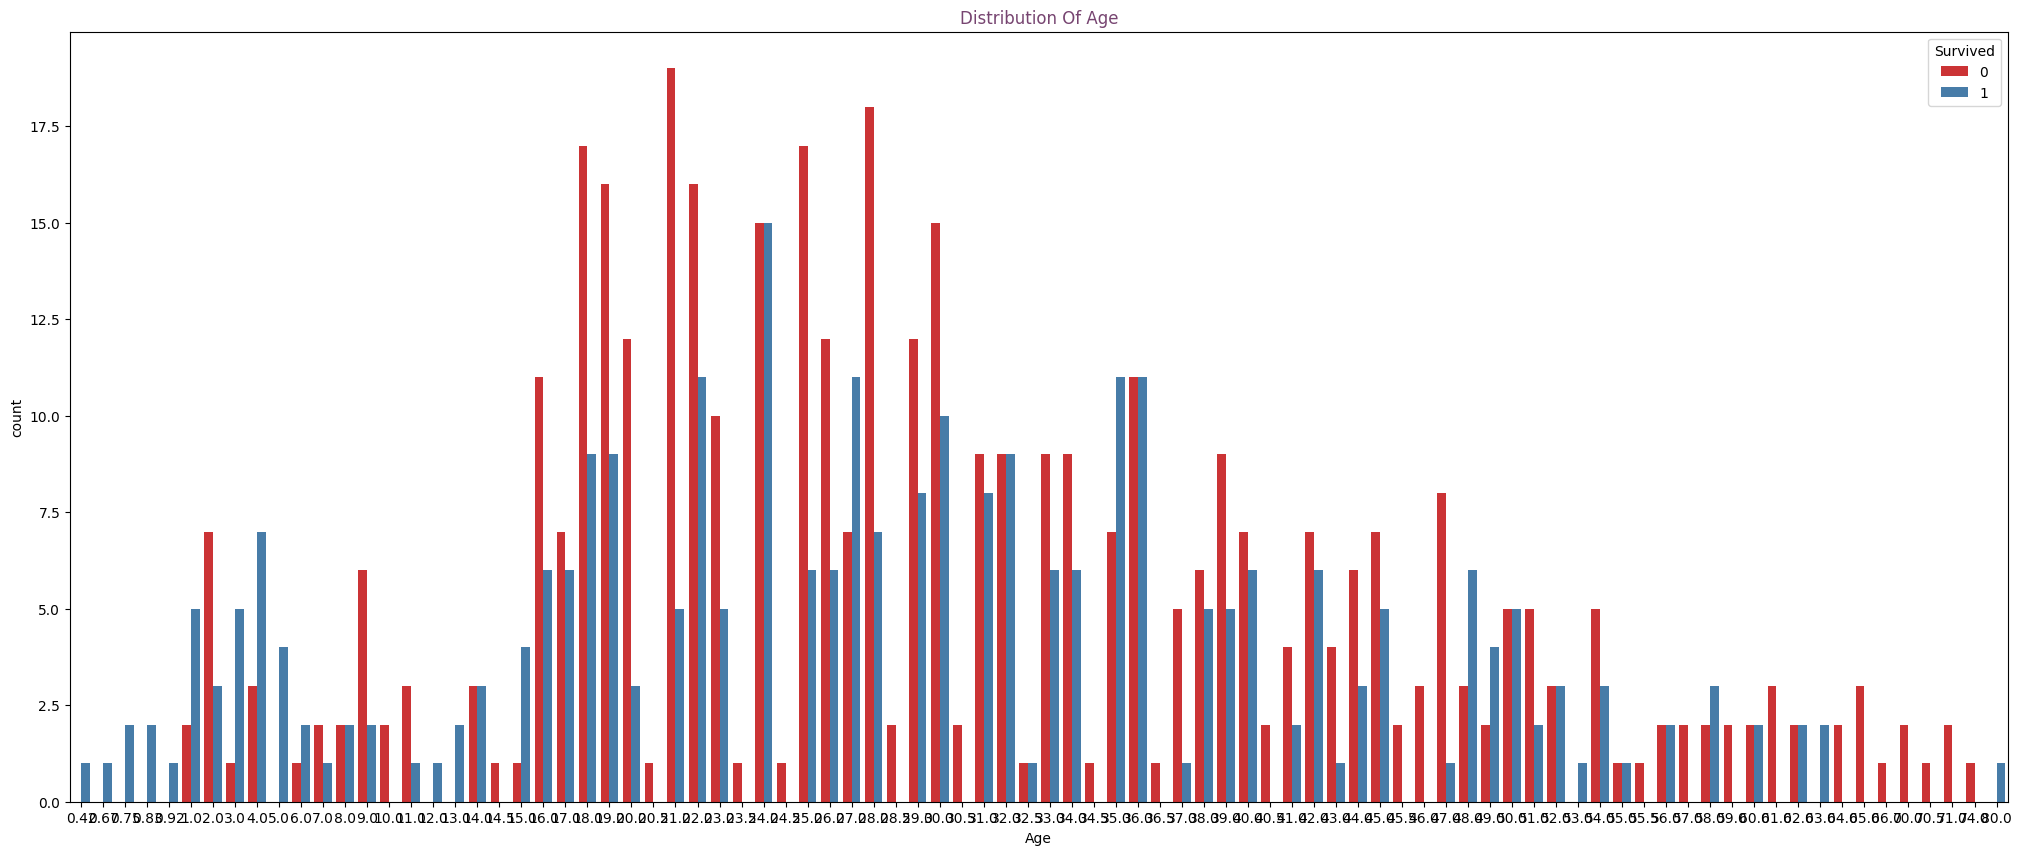

In [21]:
plt.figure(figsize=(25, 10))
Days_of_week = sns.countplot(
    x=df["Age"], data=df, hue="Survived", palette="Set1"
)
Days_of_week.set_title("Distribution Of Age", color="#774571")

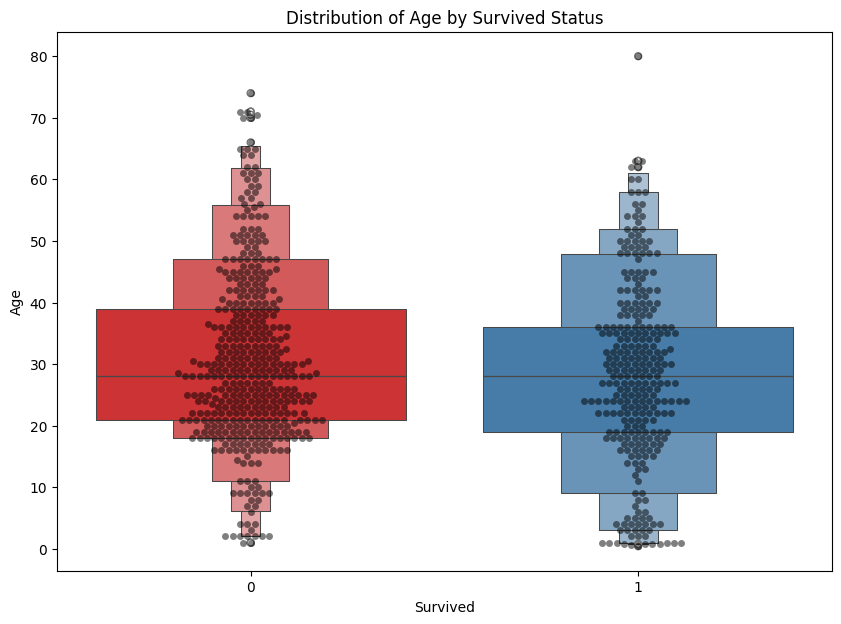

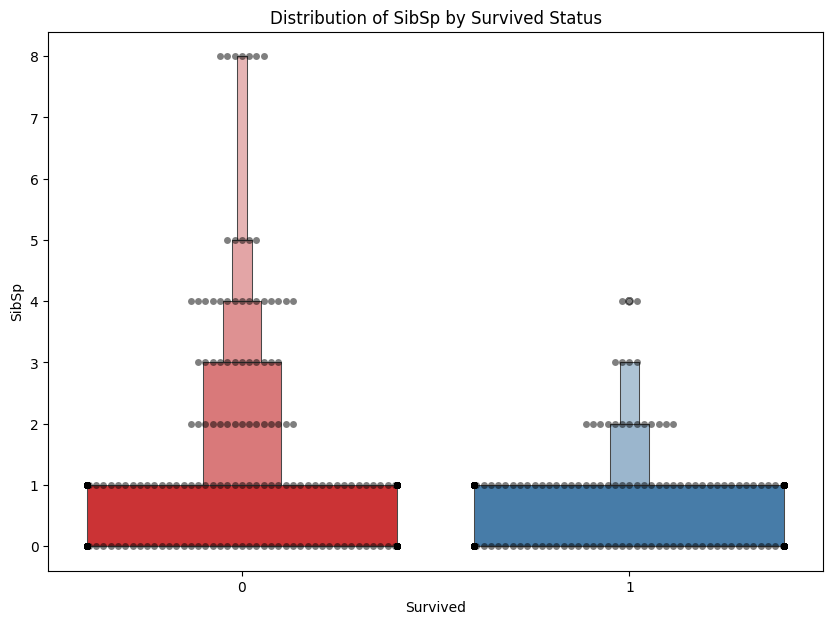

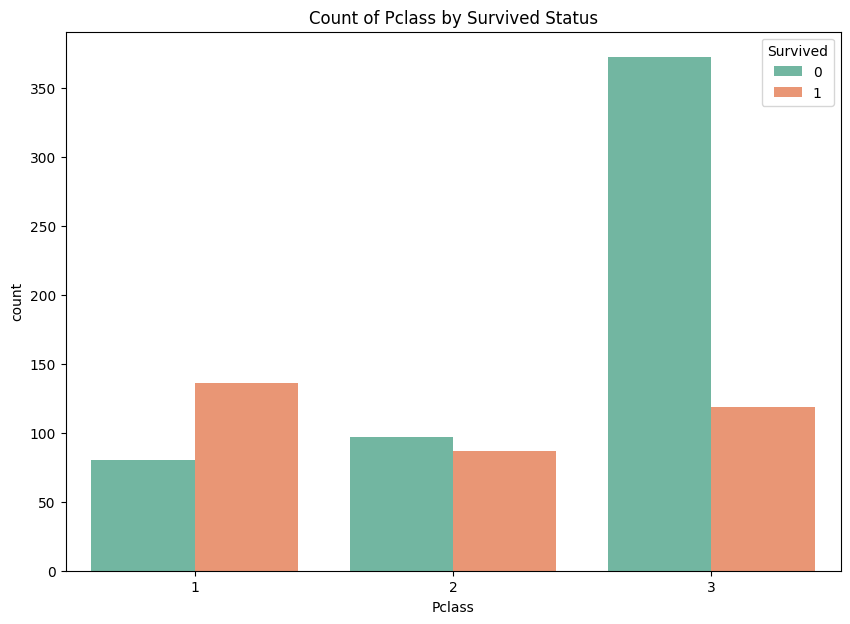

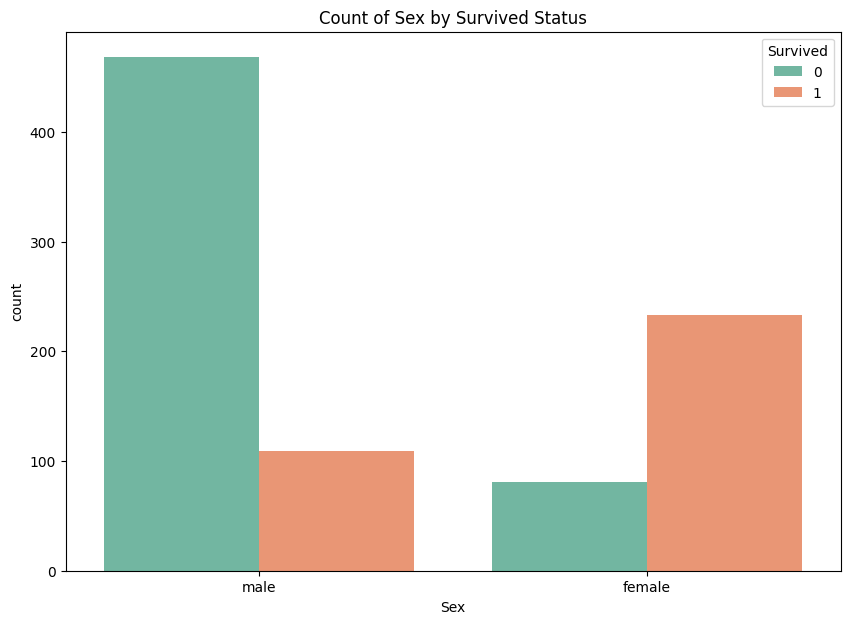

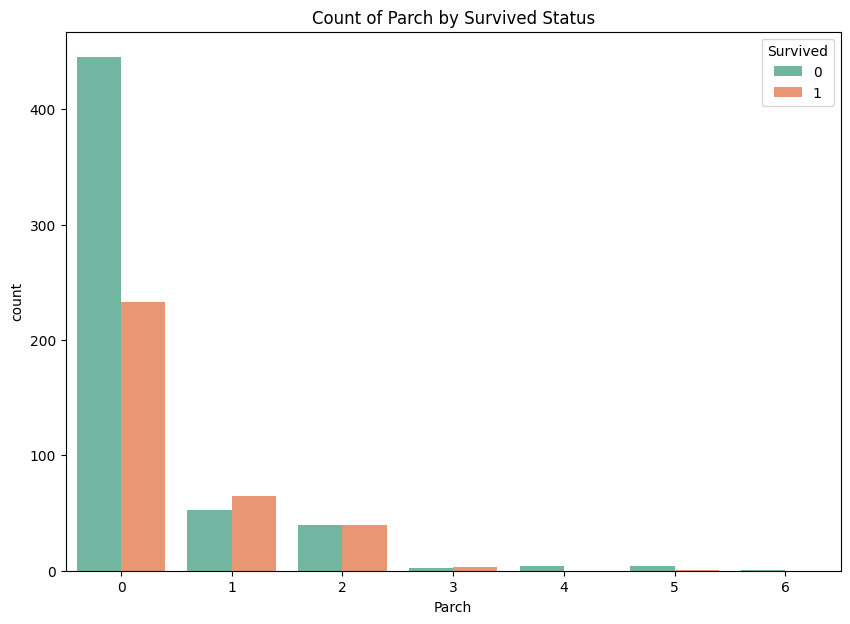

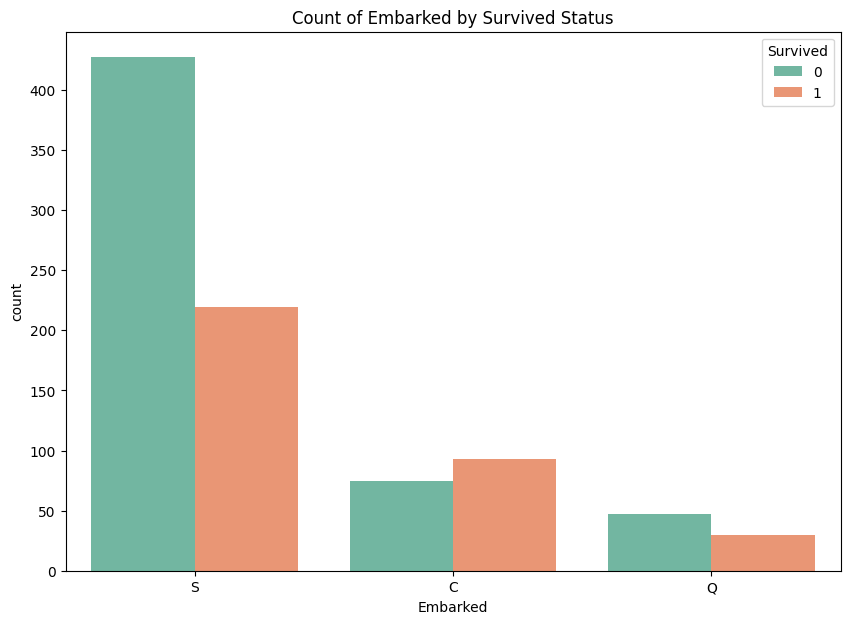

In [22]:
numerical_features = ["Age", "SibSp"]
categorical_features = ["Pclass", "Sex", "Parch", "Embarked"]

for i in numerical_features:
    plt.figure(figsize=(10, 7))
    # Use the original 'df', not 'df_encoded'
    sns.boxenplot(x=df["Survived"], y=df[i], palette="Set1")
    sns.swarmplot(x=df["Survived"], y=df[i], color="black", alpha=0.5)
    plt.title(f"Distribution of {i} by Survived Status")
    plt.show()

# 3. PLOT CATEGORICAL FEATURES (Countplot is better here)
for i in categorical_features:
    plt.figure(figsize=(10, 7))
    sns.countplot(x=df[i], hue=df["Survived"], palette="Set2")
    plt.title(f"Count of {i} by Survived Status")
    plt.show()

In [23]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [24]:
print(df["Age"].isnull().sum())

0


In [25]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [26]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'])

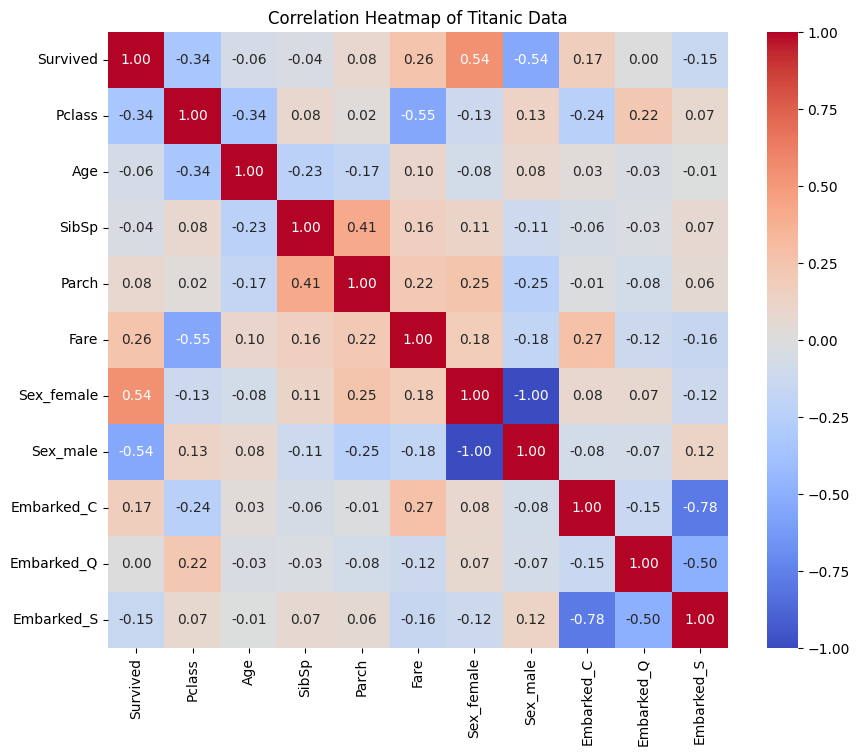

In [27]:
plt.figure(figsize=(10, 8))

sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Titanic Data')
plt.show()

## MODEL BUILDING

In [28]:
x=df.drop(["Survived"],axis=1)
y=df["Survived"]

In [29]:
print(x)
print(y)

             Pclass     Sex   Age  SibSp  Parch     Fare Embarked
PassengerId                                                      
1                 3    male  22.0      1      0   7.2500        S
2                 1  female  38.0      1      0  71.2833        C
3                 3  female  26.0      0      0   7.9250        S
4                 1  female  35.0      1      0  53.1000        S
5                 3    male  35.0      0      0   8.0500        S
...             ...     ...   ...    ...    ...      ...      ...
887               2    male  27.0      0      0  13.0000        S
888               1  female  19.0      0      0  30.0000        S
889               3  female  28.0      1      2  23.4500        S
890               1    male  26.0      0      0  30.0000        C
891               3    male  32.0      0      0   7.7500        Q

[891 rows x 7 columns]
PassengerId
1      0
2      1
3      1
4      1
5      0
      ..
887    0
888    1
889    0
890    1
891    0
Name: S

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1,6])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [31]:
print(x)

[[ 0.      1.      0.     ...  1.      0.      7.25  ]
 [ 1.      0.      1.     ...  1.      0.     71.2833]
 [ 1.      0.      0.     ...  0.      0.      7.925 ]
 ...
 [ 1.      0.      0.     ...  1.      2.     23.45  ]
 [ 0.      1.      1.     ...  0.      0.     30.    ]
 [ 0.      1.      0.     ...  0.      0.      7.75  ]]


In [32]:
# Get the new column names
column_names = ct.get_feature_names_out()

for i, name in enumerate(column_names):
    print(f"{i}: {name}")

0: encoder__Sex_female
1: encoder__Sex_male
2: encoder__Embarked_C
3: encoder__Embarked_Q
4: encoder__Embarked_S
5: remainder__Pclass
6: remainder__Age
7: remainder__SibSp
8: remainder__Parch
9: remainder__Fare


In [33]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

col_names = ct.get_feature_names_out()
s_scaler = StandardScaler()
x_scaled = s_scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=col_names)
x_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
encoder__Sex_female,891.0,3.189866e-17,1.000562,-0.737695,-0.737695,-0.737695,1.355574,1.355574
encoder__Sex_male,891.0,-1.515187e-16,1.000562,-1.355574,-1.355574,0.737695,0.737695,0.737695
encoder__Embarked_C,891.0,-3.389233e-17,1.000562,-0.482043,-0.482043,-0.482043,-0.482043,2.074505
encoder__Embarked_Q,891.0,0.000000e+00,1.000562,-0.307562,-0.307562,-0.307562,-0.307562,3.251373
encoder__Embarked_S,891.0,-5.582266e-17,1.000562,-1.623803,-1.623803,0.615838,0.615838,0.615838
remainder__Pclass,891.0,-6.379733e-17,1.000562,-1.566107,-0.369365,0.827377,0.827377,0.827377
remainder__Age,891.0,2.232906e-16,1.000562,-2.224156,-0.565736,-0.104637,0.433312,3.891554
remainder__SibSp,891.0,5.183533e-17,1.000562,-0.474545,-0.474545,-0.474545,0.432793,6.784163
remainder__Parch,891.0,2.093350e-17,1.000562,-0.473674,-0.473674,-0.473674,-0.473674,6.974147
remainder__Fare,891.0,7.256946e-16,1.000562,-0.648422,-0.489148,-0.357391,-0.024246,9.667167


In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3,random_state=12) 

print("DF",df.shape)
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

DF (891, 8)
x_train (623, 10)
x_test (268, 10)
y_train (623,)
y_test (268,)


## 1. Support Vector Machine

In [35]:
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

In [36]:
print("Evaluation for Support Vector Machine".center(75, "_"))

svm_model = svm.SVC(kernel="linear")
svm_model.fit(x_train, y_train)

svm_pred = svm_model.predict(x_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("Prediciton:    ", svm_pred)
print("_" * 75)

print("Accuracy:" + "\t" + f"{( svm_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(svm_precision * 100)}%")
print("Recall:" + "\t\t" f"{(svm_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(svm_f1 * 100)}%")
print("_" * 75)

___________________Evaluation for Support Vector Machine___________________
Prediciton:     [0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 0
 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0
 1 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 1 0 1 1 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0
 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0
 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0
 0 1 0 1 0 0 0 0 1]
___________________________________________________________________________
Accuracy:	75.74626865671642%
Precision:	71.42857142857143%
Recall:		65.42056074766354%
F1-Score:	68.29268292682927%
___________________________________________________________________________


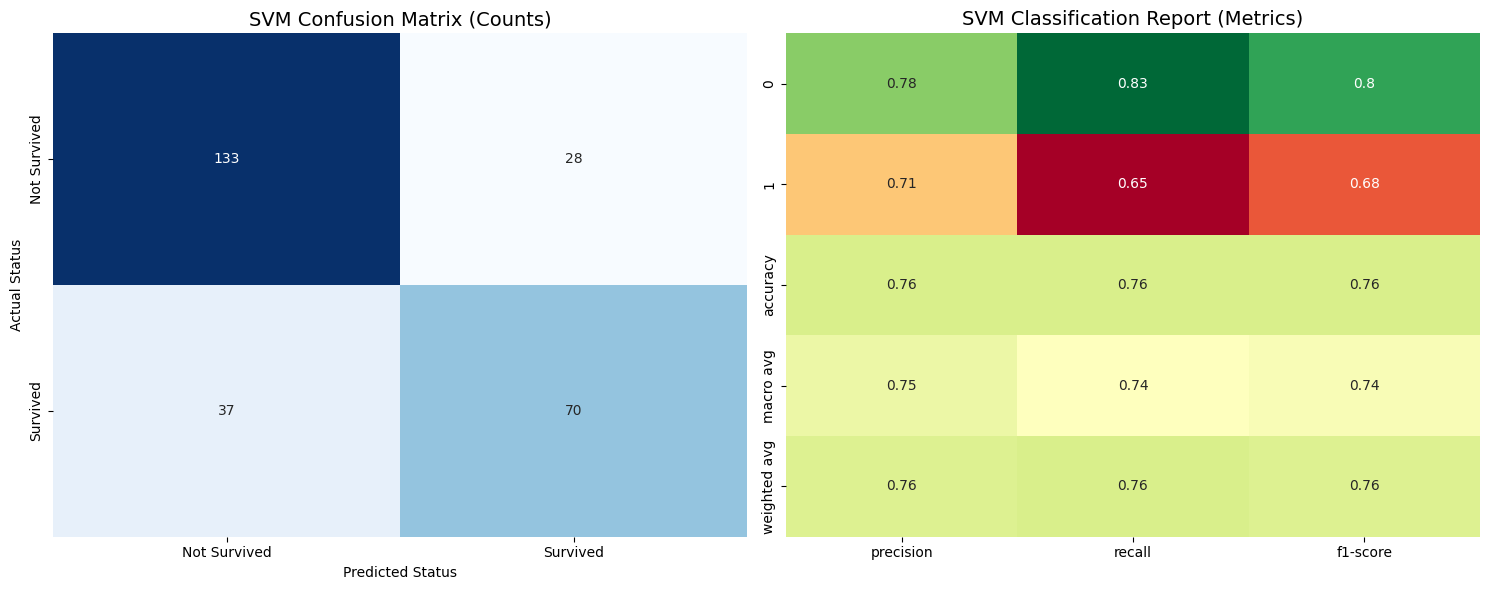

In [37]:
cm = confusion_matrix(y_test, svm_pred)
report_dict = classification_report(y_test, svm_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T  

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=['Not Survived', 'Survived'], 
            yticklabels=['Not Survived', 'Survived'])
ax[0].set_title('SVM Confusion Matrix (Counts)', fontsize=14)
ax[0].set_ylabel('Actual Status')
ax[0].set_xlabel('Predicted Status')

sns.heatmap(report_df, annot=True, cmap='RdYlGn', cbar=False, ax=ax[1])
ax[1].set_title('SVM Classification Report (Metrics)', fontsize=14)

plt.tight_layout()
plt.show()

## 2. KNeighborsClassifier

In [38]:
print("Evaluation for K-Nearest Neighbors".center(75, "_"))

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)

knn_pred = knn_model.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("Prediciton:    ", knn_pred)
print("_" * 75)

print("Accuracy:" + "\t" + f"{(knn_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(knn_precision * 100)}%")
print("Recall:" + "\t\t" f"{(knn_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(knn_f1 * 100)}%")
print("_" * 75)

_____________________Evaluation for K-Nearest Neighbors____________________
Prediciton:     [0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 1 1 1 0 1 0 0 1 0 0 1 0
 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0
 1 1 0 0 1 0 1 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 1 1
 1 1 0 1 1 1 0 1 0 1 0 0 0 1 1 1 1 1 1 0 1 0 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0
 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 1 1 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1 1 0 0
 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 1]
___________________________________________________________________________
Accuracy:	74.6268656716418%
Precision:	71.91011235955057%
Recall:		59.813084112149525%
F1-Score:	65.3061224489796%
___________________________________________________________________________


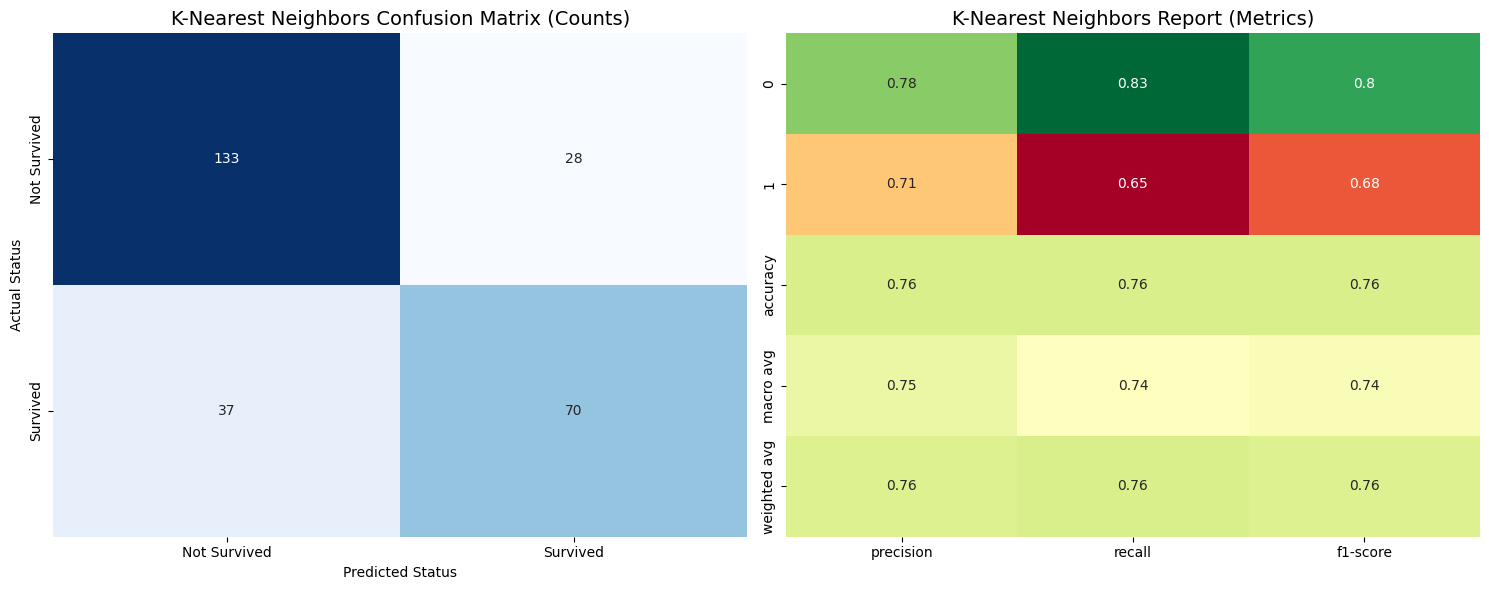

In [39]:
cm = confusion_matrix(y_test, svm_pred)
report_dict = classification_report(y_test, svm_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T  

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=['Not Survived', 'Survived'], 
            yticklabels=['Not Survived', 'Survived'])
ax[0].set_title('K-Nearest Neighbors Confusion Matrix (Counts)', fontsize=14)
ax[0].set_ylabel('Actual Status')
ax[0].set_xlabel('Predicted Status')

sns.heatmap(report_df, annot=True, cmap='RdYlGn', cbar=False, ax=ax[1])
ax[1].set_title('K-Nearest Neighbors Report (Metrics)', fontsize=14)

plt.tight_layout()
plt.show()

## 3. Logistic Regression

In [40]:
print("Evaluation for Logistic Regression".center(75, "_"))

log_model = LogisticRegression()
log_model.fit(x_train, y_train)

log_pred = log_model.predict(x_test)
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Prediciton:    ", log_pred)
print("_" * 75)

print("Accuracy:" + "\t" + f"{(log_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(log_precision * 100)}%")
print("Recall:" + "\t\t" f"{(log_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(log_f1 * 100)}%")
print("_" * 75)

_____________________Evaluation for Logistic Regression____________________
Prediciton:     [0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 0 1 0
 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 1 0 1 1 1 0 0 0 0 0 1
 1 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 1 0 1 1 0 0 1 0 0 1 1 0 1
 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0
 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0
 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0
 0 1 0 1 0 0 0 0 1]
___________________________________________________________________________
Accuracy:	78.73134328358209%
Precision:	76.59574468085107%
Recall:		67.28971962616822%
F1-Score:	71.64179104477611%
___________________________________________________________________________


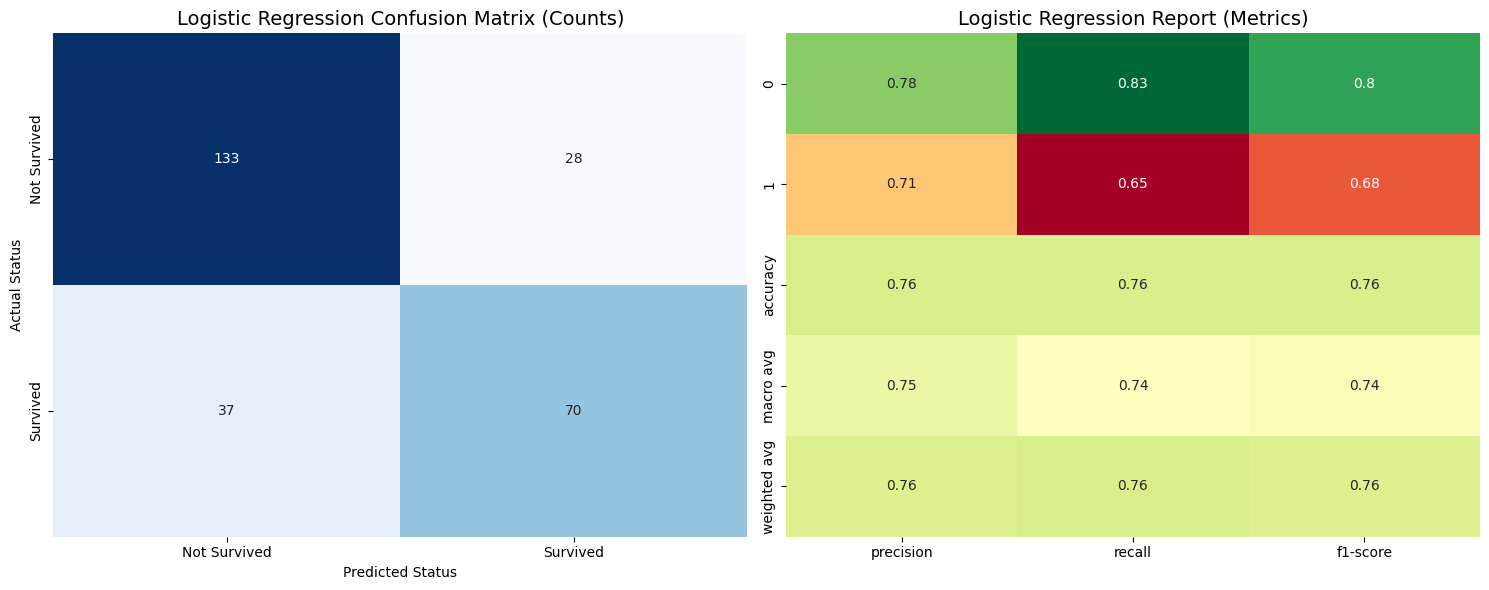

In [41]:
cm = confusion_matrix(y_test, svm_pred)
report_dict = classification_report(y_test, svm_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T  

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=['Not Survived', 'Survived'], 
            yticklabels=['Not Survived', 'Survived'])
ax[0].set_title('Logistic Regression Confusion Matrix (Counts)', fontsize=14)
ax[0].set_ylabel('Actual Status')
ax[0].set_xlabel('Predicted Status')

sns.heatmap(report_df, annot=True, cmap='RdYlGn', cbar=False, ax=ax[1])
ax[1].set_title('Logistic Regression Report (Metrics)', fontsize=14)

plt.tight_layout()
plt.show()

## COMPARISON

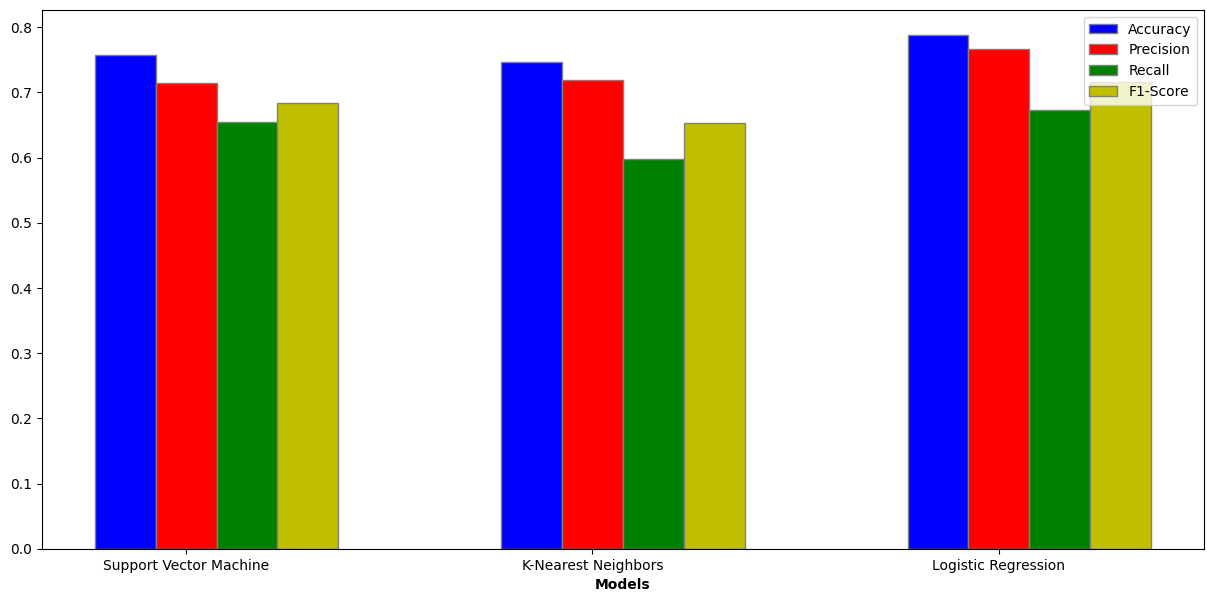

In [42]:
models = ["Support Vector Machine", "K-Nearest Neighbors", "Logistic Regression"]
accuracy = [svm_accuracy, knn_accuracy, log_accuracy]
precision = [svm_precision, knn_precision, log_precision]
recall = [svm_recall, knn_recall, log_recall]
f1 = [svm_f1, knn_f1, log_f1]

barWidth = 0.15

r1 = np.arange(len(accuracy))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]

plt.figure(figsize=(15, 7))

plt.bar(r1, accuracy, color="b", width=barWidth, edgecolor="grey", label="Accuracy")
plt.bar(r2, precision, color="r", width=barWidth, edgecolor="grey", label="Precision")
plt.bar(r3, recall, color="g", width=barWidth, edgecolor="grey", label="Recall")
plt.bar(r4, f1, color="y", width=barWidth, edgecolor="grey", label="F1-Score")

plt.xlabel("Models", fontweight="bold")
plt.xticks([r + barWidth for r in range(len(accuracy))], models)

plt.legend()
plt.show()